In [14]:
!pip install lime

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


In [16]:
# Step 1: Load a subset of the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)

# Split the dataset into two parts for the two local models
data_len = len(mnist_dataset)
local_data_len = data_len // 2
local_data_1, local_data_2 = random_split(mnist_dataset, [local_data_len, data_len - local_data_len])

# Create DataLoader for each local dataset
local_loader_1 = DataLoader(local_data_1, batch_size=32, shuffle=True)
local_loader_2 = DataLoader(local_data_2, batch_size=32, shuffle=True)

In [17]:
# Step 2: Define a simple neural network model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        #x = x.view(-1, 28 * 28)
        x = x.reshape(-1, 28 * 28) # use reshape instead of view
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize two local models
local_model_1 = SimpleNN()
local_model_2 = SimpleNN()

# Define loss function and optimizers
criterion = nn.CrossEntropyLoss()
optimizer_1 = optim.SGD(local_model_1.parameters(), lr=0.01)
optimizer_2 = optim.SGD(local_model_2.parameters(), lr=0.01)


In [18]:
# Step 3: Train the local models
def train(model, data_loader, optimizer, criterion, epochs=1):
    model.train()
    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(data_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

train(local_model_1, local_loader_1, optimizer_1, criterion, epochs=2)
train(local_model_2, local_loader_2, optimizer_2, criterion, epochs=2)

In [19]:
# Step 4: Simulate federated learning by averaging the weights
def average_weights(model_1, model_2):
    global_model = SimpleNN()
    global_dict = global_model.state_dict()

    # Average the parameters
    for key in global_dict.keys():
        global_dict[key] = (model_1.state_dict()[key] + model_2.state_dict()[key]) / 2

    global_model.load_state_dict(global_dict)
    return global_model

global_model = average_weights(local_model_1, local_model_2)

In [20]:
# Step 5: Test the global model
def test(model, data_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in data_loader:
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(data_loader.dataset)
    accuracy = 100. * correct / len(data_loader.dataset)
    return test_loss, accuracy

# Load test data
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Test the global model
test_loss, test_accuracy = test(global_model, test_loader, criterion)

# Print results
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

Test Loss: 0.0008, Test Accuracy: 86.26%


In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn as nn
import numpy as np
import os

import torch
from torchvision import models, transforms, datasets
from torch.autograd import Variable
import torch.nn.functional as F

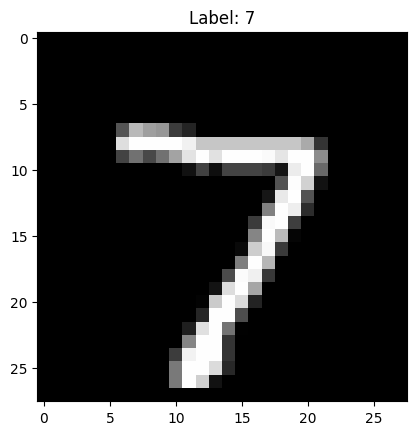

In [35]:
# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Get a single image from the dataset
def get_image(index):
    img, label = mnist_dataset[index]
    return img, label

# Display the image
img, label = get_image(0)
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.show()


In [36]:
# Transformation to convert the image into 3-channel (RGB) and resize it
def get_pil_transform():
    return transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.Grayscale(num_output_channels=3)  # Convert to RGB by duplicating channels
    ])

# Normalization step required by the model (even though our model might not need the same as ImageNet)
def get_preprocess_transform():
    return transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

pill_transf = get_pil_transform()
preprocess_transform = get_preprocess_transform()


In [39]:
model = global_model

In [43]:
# Define the batch prediction function
def batch_predict(images):
    model.eval()

    # Convert all images to tensors and process them in batches
    batch_size = 50  # Adjust this batch size as needed
    preds = []

    for i in range(0, len(images), batch_size):
        batch = images[i:i + batch_size]  # Get the batch of images
        batch = torch.stack([preprocess_transform(Image.fromarray(img)) for img in batch], dim=0)  # Preprocess each image

        with torch.no_grad():
            logits = model(batch)
            probs = F.softmax(logits, dim=1)
            preds.append(probs.cpu().numpy())

    return np.concatenate(preds, axis=0)  # Ensure the return value is a single array with all predictions

  0%|          | 0/10000 [00:00<?, ?it/s]

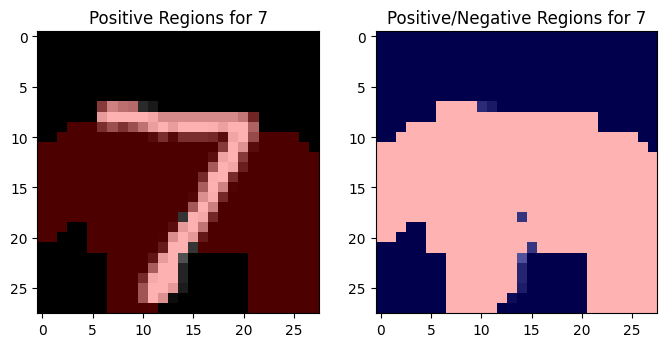

In [52]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from lime.wrappers.scikit_image import SegmentationAlgorithm
from skimage.color import gray2rgb, label2rgb, rgb2gray
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Assume global_model is already defined from your previous code

# Step 1: Prepare the Data
# Load a subset of the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
mnist_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

# Convert the first image in the test set to a numpy array
test_loader = DataLoader(mnist_dataset, batch_size=1, shuffle=False)
test_data_iter = iter(test_loader)
data, target = next(test_data_iter)
data_np = data.squeeze().numpy()  # Shape (1, 28, 28) -> (28, 28)

# Convert to 3-channel grayscale image for LIME
data_rgb = gray2rgb(data_np)

# Step 2: Define the classifier function for LIME
def classifier_fn(images):
    images = torch.tensor([rgb2gray(img).reshape(1, 28, 28) for img in images], dtype=torch.float32)
    images = images.reshape(-1, 28 * 28)
    with torch.no_grad():
        logits = global_model(images)
    return torch.softmax(logits, dim=1).numpy()

# Step 3: Use LIME for explanation
explainer = lime_image.LimeImageExplainer()
segmenter = SegmentationAlgorithm('quickshift', kernel_size=1, max_dist=200, ratio=0.2)

# Explain the first image in the test set
explanation = explainer.explain_instance(data_rgb,
                                         classifier_fn=classifier_fn,
                                         top_labels=10,
                                         hide_color=0,
                                         num_samples=10000,
                                         segmentation_fn=segmenter)

# Step 4: Display the explanation for both positive and positive/negative regions
temp, mask = explanation.get_image_and_mask(target.item(), positive_only=True, num_features=10, hide_rest=False, min_weight=0.01)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Positive only regions
ax1.imshow(label2rgb(mask, temp, bg_label=0), interpolation='nearest')
ax1.set_title('Positive Regions for {}'.format(target.item()))

# Positive and Negative regions
temp, mask = explanation.get_image_and_mask(target.item(), positive_only=False, num_features=10, hide_rest=False, min_weight=0.01)
ax2.imshow(label2rgb(3-mask, temp, bg_label=0), interpolation='nearest')
ax2.set_title('Positive/Negative Regions for {}'.format(target.item()))

plt.show()

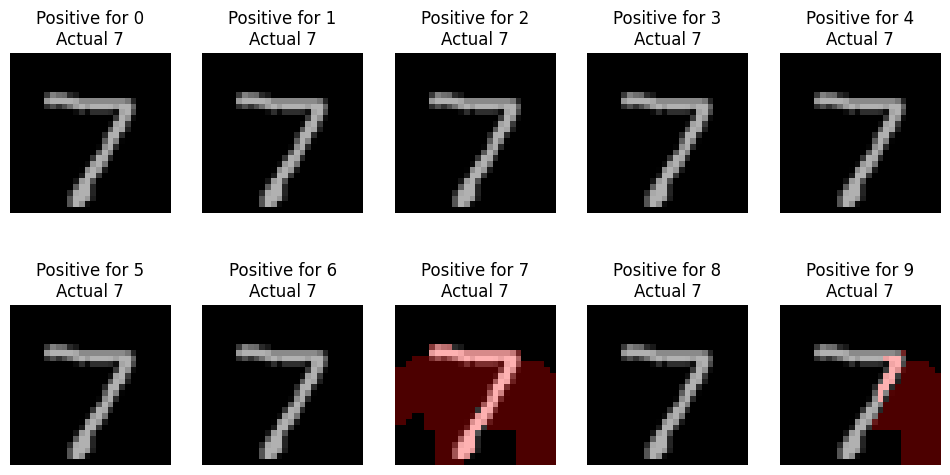

In [51]:
# Step 4: Display the explanation for each class
fig, m_axs = plt.subplots(2, 5, figsize=(12, 6))
for i, c_ax in enumerate(m_axs.flatten()):
    temp, mask = explanation.get_image_and_mask(i, positive_only=True, num_features=10, hide_rest=False, min_weight=0.01)
    c_ax.imshow(label2rgb(mask, temp, bg_label=0), interpolation='nearest')
    c_ax.set_title('Positive for {}\nActual {}'.format(i, target.item()))
    c_ax.axis('off')
plt.show()

In [54]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 9.3 MB/s eta 0:00:00


  0%|          | 0/3 [00:00<?, ?it/s]

Shape of x_test_images after squeezing: (3, 28, 28)
Shape of shap_values: (3, 784, 10)


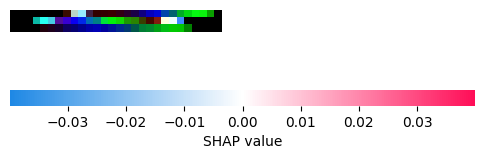

In [61]:
import torch
import shap
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Step 1: Prepare the Test Data
transform = transforms.Compose([transforms.ToTensor()])
mnist_test = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(mnist_test, batch_size=1000, shuffle=False)
x_test, y_test = next(iter(test_loader))

# Reshape the data as required for the model (flatten)
x_test_flattened = x_test.view(x_test.size(0), -1)

# Step 2: Define the SHAP Explainer using KernelExplainer
global_model.eval()  # Set the model to evaluation mode

# SHAP expects a function that takes numpy arrays or tensors as input
def model_fn(inputs):
    inputs = torch.tensor(inputs, dtype=torch.float32)
    with torch.no_grad():
        return global_model(inputs).numpy()

# Initialize SHAP KernelExplainer
explainer = shap.KernelExplainer(model_fn, x_test_flattened[:100].numpy())

# Step 3: Generate SHAP Values for a Subset of the Test Set
shap_values = explainer.shap_values(x_test_flattened[:3].numpy())

# Step 4: Reshape the images for plotting
# SHAP expects inputs to be in the shape (samples, width, height, channels)
x_test_images = x_test[:3].squeeze().numpy()  # Remove the channel dimension since it's 1

# Check shape after squeezing
print(f"Shape of x_test_images after squeezing: {x_test_images.shape}")
print(f"Shape of shap_values: {np.array(shap_values).shape}")

# Step 5: Visualize the SHAP Values
shap.image_plot(shap_values, x_test_images)
